In [2]:
import os
print(os.getcwd())

/home/mth168/Lab5


In [4]:
%matplotlib inline

In [5]:
#lets import the vectors
import geopandas as gpd
# Import the sample elevation (altimetry) points 
points = gpd.read_file('Lab5_Data/CAT_Object_pt.shp')
# Import Canchim's boundary
lim = gpd.read_file('Lab5_Data/recorte_pol.shp')

# Check if they have the same CRs
points.crs == lim.crs

/shared/prefix2025/easybuild/software/rockylinux/9.5/amd/zen3/software/geopandas/1.0.1-foss-2024a/lib/python3.12/site-packages/pyogrio/raw.py:198: UserWarning: Measured (M) geometry types are not supported. Original type 'Measured 3D Point' is converted to 'Point Z'
  return ogr_read(


True

In [6]:
points.crs #Inspect their CRS

<Projected CRS: EPSG:32723>
Name: WGS 84 / UTM zone 23S
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Between 48°W and 42°W, southern hemisphere between 80°S and equator, onshore and offshore. Brazil.
- bounds: (-48.0, -80.0, -42.0, 0.0)
Coordinate Operation:
- name: UTM zone 23S
- method: Transverse Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [7]:
points.head(3)

,FID,Avg_z,geometry
0,1,698.0,POINT Z (209750 7571250 698)
1,2,702.0,POINT Z (208750 7571250 702)
2,3,695.0,POINT Z (209750 7573000 695)


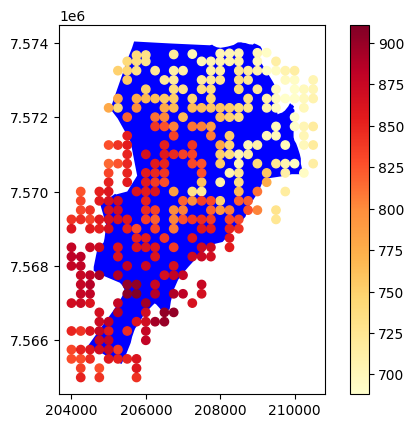

In [8]:
#Let’s quickly visualize the sample points by plotting their location and Avg_z (average altimetry), and and plotting the limit:
# Import the necessary library for creating plots
import matplotlib.pyplot as plt
# Create a new figure and axis for the plot
fig, ax = plt.subplots()

# Plot the data from the "lim" dataset with blue color onto the specified axis
lim.plot(color='blue', ax=ax)
# Plot the data from the "points" dataset with coloring based on the "Avg_z" column
# Also, display a legend for the plot
points.plot(column="Avg_z", ax=ax, legend=True, cmap= 'YlOrRd')

# Display the final plot
plt.show()

In [9]:
#Spatial interpolation
#Split samples using sklearn
#We will split our data using the random sampling:
# Import the necessary library for splitting data into training and test sets
from sklearn.model_selection import train_test_split
# Split the GeoDataFrame (points) into training and test sets
# The test set will contain 35% of the data, and the random_state is set to 42
train, test = train_test_split(points, test_size=0.35, random_state=42)


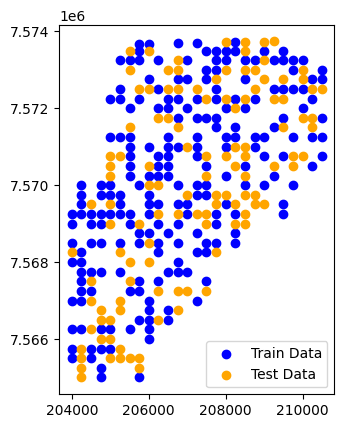

In [10]:
#Let’s visualize the distribution of our test and training sets:
# Create a new figure and axis for the plot
fig, ax = plt.subplots()

# Plot the "train" data using blue color onto the specified axis
train.plot(color='blue', ax=ax,label='Train Data')

# Plot the "test" data using green color onto the same axis
test.plot(color='orange', ax=ax, label='Test Data')
# Add a legend to the plot
ax.legend()
# Display the plot
plt.show()

In [11]:
train.head()

,FID,Avg_z,geometry
204,205,845.0,POINT Z (204500 7565500 845)
18,19,702.0,POINT Z (207250 7573695 702)
311,312,879.0,POINT Z (206000 7566000 879)
246,247,856.0,POINT Z (206000 7570250 856)
19,20,694.0,POINT Z (209500 7573250 694)


In [12]:
#extract the vaues of coordinates and altimetry to separate variables\
# Extract the x-coordinates of the geometries in the 'train' dataset
x = train.geometry.x

# Extract the y-coordinates of the geometries in the 'train' dataset
y = train.geometry.y

# Extract the values from the 'Avg_z' column of the 'train' dataset
z = train['Avg_z']
print(x)
print(y)
print(z)

204    204500.0
18     207250.0
311    206000.0
246    206000.0
19     209500.0
         ...   
188    208250.0
71     205750.0
106    205250.0
270    206500.0
102    205250.0
Length: 213, dtype: float64
204    7565500.0
18     7573695.0
311    7566000.0
246    7570250.0
19     7573250.0
         ...    
188    7569250.0
71     7573250.0
106    7573250.0
270    7567750.0
102    7572500.0
Length: 213, dtype: float64
204    845.0
18     702.0
311    879.0
246    856.0
19     694.0
       ...  
188    832.0
71     735.0
106    749.0
270    867.0
102    780.0
Name: Avg_z, Length: 213, dtype: float64


In [14]:
#Creating a prediction grid using numpy
# Import the necessary library
import numpy as np
# Get the minimum and maximum values of x and y coordinates from the 'points' dataset
xmin, ymin, xmax, ymax = points.total_bounds
# Create a grid of x-coordinates with a spacing of 10 units, extending 5 units beyond the dataset bounds
gridx = np.arange(xmin - 5, xmax + 5, 10, dtype='float64')
# Create a grid of y-coordinates with a spacing of 10 units, extending 5 units beyond the dataset bounds
gridy = np.arange(ymin - 5, ymax + 5, 10, dtype='float64')
# Create a meshgrid from the x and y coordinate grids
xi, yi = np.meshgrid(gridx, gridy)

In [15]:
#Nearest neighbour interpolation using scipy
# scipy is a fundamental library for scientific computing in Python.
#Let’s use the nearest neighbour interpolator from scipy to generate a surface from our training altimetry points:
# Import the NearestNDInterpolator class from the scipy.interpolate module
from scipy.interpolate import NearestNDInterpolator
# Create a NearestNDInterpolator using the provided x, y, and z values
# This interpolator uses nearest neighbor interpolation
nnb_interp = NearestNDInterpolator(list(zip(x, y)), z)
# Use the nnb interpolator to interpolate values at the points defined by the xi and yi meshgrid
nnb_z = nnb_interp(xi, yi)
# Inspect the results
# Print the type of nnb_z, which should indicate the type of data structure used for the interpolated values
print(type(nnb_z))

# Print the nnb_z array, which contains the interpolated values
print(nnb_z)

<class 'numpy.ndarray'>
[[829. 829. 829. ... 864. 864. 864.]
 [829. 829. 829. ... 864. 864. 864.]
 [829. 829. 829. ... 864. 864. 864.]
 ...
 [749. 749. 749. ... 715. 715. 715.]
 [749. 749. 749. ... 715. 715. 715.]
 [749. 749. 749. ... 715. 715. 715.]]


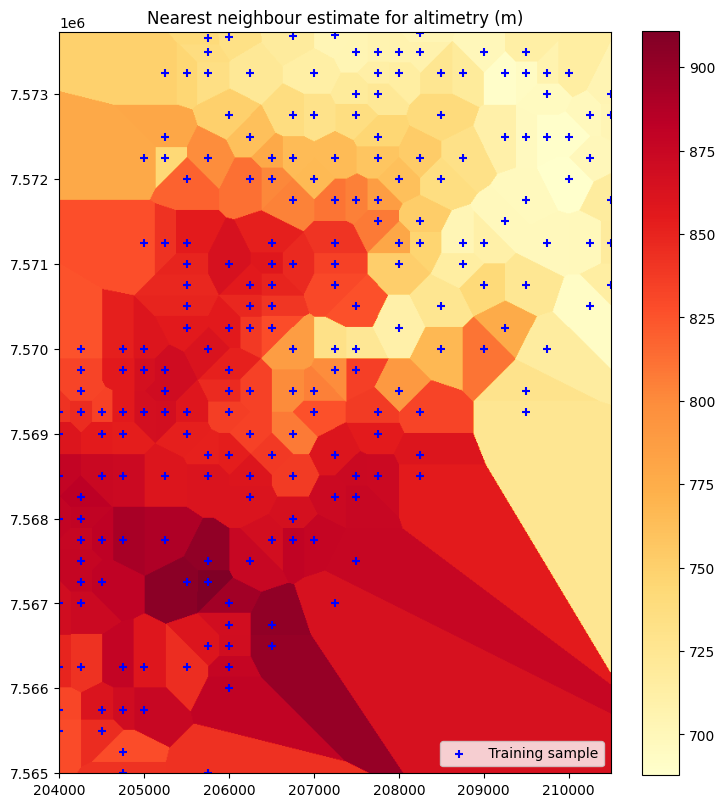

In [16]:
#Visualize the results from the nearest neighbour(NN) interpolation:
# Create a new figure and axis for the plot with a specific size
fig, ax = plt.subplots(figsize=(8, 10))
# Display the interpolated data as an image on the axis
# Note that by default imshow assumes that the pixel coordinate orgin (0,0) starts at the top left corner
# however our interpolated result nnb_z has the pixel coordinate orgin (0,0) starting at the lower left corner
# thats is why we need to specify origin='lower'
cax = ax.imshow(nnb_z, extent=(xmin, xmax, ymin, ymax), origin='lower',cmap='YlOrRd')
# Add the training samples as blue plus markers on the plot
train.plot(color='blue', ax=ax, marker='+', label=" Training sample")
# Add a colorbar to the plot with a specified size (fraction of the plot height)
cbar = plt.colorbar(cax, fraction=0.06)

# Add a legend to the plot to indicate the training sample
ax.legend()

# Set the title for the plot
plt.title('Nearest neighbour estimate for altimetry (m)')

# Display the final plot
plt.show()

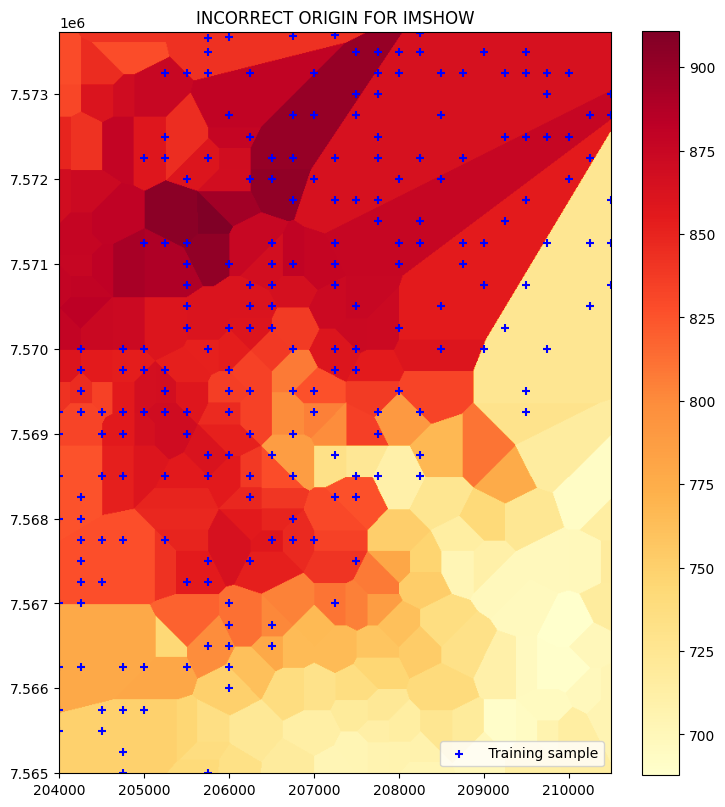

In [17]:
#Visualize the results from the nearest neighbour(NN) interpolation without the origin=‘lower’ argument 
# Create a new figure and axis for the plot with a specific size
fig, ax = plt.subplots(figsize=(8, 10))

# Display the interpolated data as an image on the axis
# Notice that the pixel coordinate orgin (0,0) starts at the top left corner by default
cax = ax.imshow(nnb_z, extent=(xmin, xmax, ymin, ymax), cmap='YlOrRd')

# Add the training samples as blue plus markers on the plot
train.plot(color='blue', ax=ax, marker='+', label=" Training sample")

# Add a colorbar to the plot with a specified size (fraction of the plot height)
cbar = plt.colorbar(cax, fraction=0.06)

# Add a legend to the plot to indicate the training sample
ax.legend()

# Set the title for the plot
plt.title('INCORRECT ORIGIN FOR IMSHOW')

# Display the final plot
plt.show()

In [18]:
def calc_distance_matrix(x_observed, y_observed, x_interpolation, y_interpolation):
    # Combine x and y coordinates of observed points into a numpy array
    observed_points = np.column_stack((x_observed, y_observed))
    
    # Combine x and y coordinates of interpolation points into a numpy array
    interpolation_points = np.column_stack((x_interpolation, y_interpolation))

    # Calculate differences between x-coordinates of observed and interpolation points - side a
    x_differences = np.subtract.outer(observed_points[:, 0], interpolation_points[:, 0])

    # Calculate differences between y-coordinates of observed and interpolation points - side b
    y_differences = np.subtract.outer(observed_points[:, 1], interpolation_points[:, 1])

    # Calculate Euclidean distances between observed and interpolation
    # points using Pythagorean theorem - hypotenuse c  
    distance_matrix = np.hypot(x_differences, y_differences)
    
    return distance_matrix

In [20]:
#Inverse Distance Weighting (IDW)
#Inverse Distance Weighting (IDW) is used to estimate the value of a point at an unobserved location based on the values of surrounding observed points.
#Apply calc_distance_matrix to generate a pairwise distance matrix between our observed and prediction points
# The .flatten() method is used to convert a multi-dimensional array (such as a matrix) into a 1-dimensional array,
# effectively "flattening" it.
dist = calc_distance_matrix(x,y,xi.flatten(),yi.flatten())

# Inspect the result
dist

array([[  714.177849  ,   707.14213564,   700.17854866, ...,
        10174.27392987, 10180.14980243, 10186.03210284],
       [ 9288.97330172,  9285.47387051,  9281.98389354, ...,
         3225.24805248,  3235.24728576,  3245.24652376],
       [ 2242.77729612,  2233.84198188,  2224.91572874, ...,
         8936.21004677,  8941.22195228,  8946.24222789],
       ...,
       [ 8349.85329212,  8348.35612561,  8346.8706711 , ...,
         5247.46129095,  5257.41856808,  5267.37600708],
       [ 3723.58026636,  3716.86023412,  3710.15498329, ...,
         7184.76513186,  7190.30249711,  7195.84949815],
       [ 7609.20823739,  7607.56531355,  7605.93518247, ...,
         5368.97103736,  5378.70337535,  5388.43669351]])

In [21]:
# we need to create a fuction that uses the distance matrix dist, the observed values and the coordinates to compute the IDW interpolation:
def idw(x_observed, y_observed, z_observed, x_interpolation, y_interpolation, power, distance_matrix):
    # Calculate weights using the inverse of the distance raised to the power
    weights = 1.0 / distance_matrix**power
    
    # Normalize weights to ensure they sum up to one for each interpolated point
    normalized_weights = weights / weights.sum(axis=0)
    
    # Calculate interpolated values using weighted average of observed Z-values
    # The .T is used to transpose a matrix or an array in Python. Transposing a 
    # matrix means swapping its rows with columns, effectively rotating the matrix
    # by 90 degrees. np.dot performs dot product multiplication between two arrays
    interpolated_values = np.dot(normalized_weights.T, z_observed)
    
    return interpolated_values

In [22]:
#Let’s apply the idw function to our data using power of 2:
# Interpolate the z values using the IDW function
# Provide observed (x, y, z) data, interpolation locations (xi, yi)
# power parameter for IDW, and precalculated distance matrix
idw_z2 = idw(x, y, z, xi, yi, power=2, distance_matrix=dist)

# Reshape the interpolated z values to match the dimensions of 
# the grid covering Canchim
idw_z2 = idw_z2.reshape((len(gridy), len(gridx)))

# Inspect the result
idw_z2

array([[843.75220501, 843.77861836, 843.80617584, ..., 817.01135357,
        816.94589335, 816.88058823],
       [843.70140385, 843.72872758, 843.75732497, ..., 816.98736139,
        816.92178494, 816.85636439],
       [843.64667851, 843.67496165, 843.70465979, ..., 816.96319498,
        816.89750228, 816.8319663 ],
       ...,
       [786.53689666, 786.4028999 , 786.26798616, ..., 728.70587656,
        728.81742839, 728.92948926],
       [786.4832013 , 786.34945061, 786.21478971, ..., 728.90169152,
        729.01271959, 729.12424894],
       [786.43022263, 786.29672411, 786.16232222, ..., 729.09648967,
        729.20696822, 729.3179412 ]])

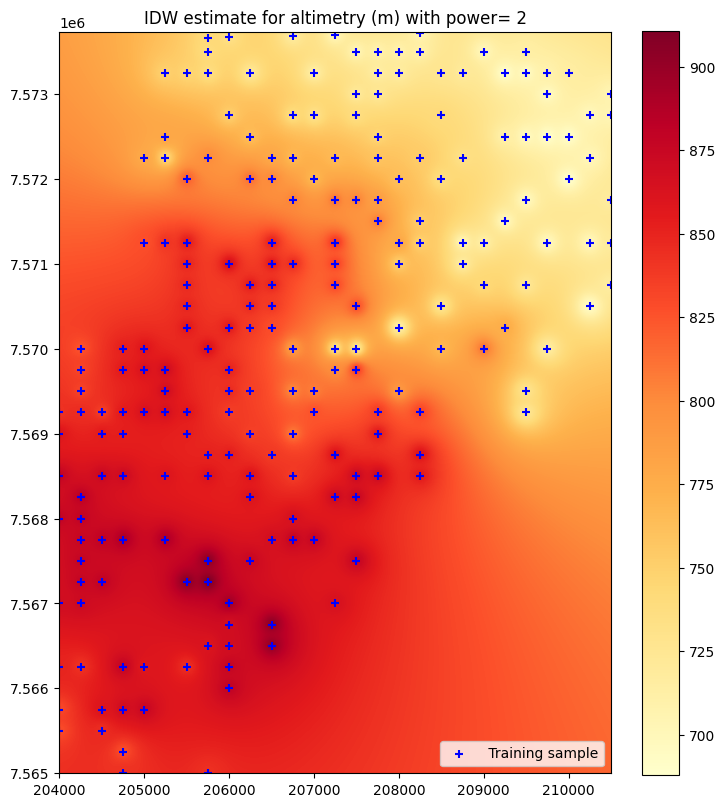

In [23]:
# Create a new figure and axis for the plot with a specific size
fig, ax = plt.subplots(figsize=(8, 10))

# Display the interpolated data as an image on the axis
# Note: By default, imshow assumes that the pixel coordinate origin (0,0) starts at the top left corner.
# However, our interpolated result idw_z2 has the pixel coordinate origin (0,0) starting at the lower left corner.
# That's why we need to specify origin='lower' to correctly display the image.
cax = ax.imshow(idw_z2, extent=(xmin, xmax, ymin, ymax), origin='lower', cmap='YlOrRd')

# Add the training samples as blue plus markers on the plot
train.plot(color='blue', ax=ax, marker='+', label=" Training sample")

# Add a colorbar to the plot with a specified size (fraction of the plot height)
cbar = plt.colorbar(cax, fraction=0.06)

# Add a legend to the plot to indicate the training sample
ax.legend()

# Set the title for the plot
plt.title('IDW estimate for altimetry (m) with power= 2')

# Display the final plot
plt.show()

In [24]:
#Perform a new idw interpolation with power = 5 and plot the result
idw_z5 = idw(x, y, z, xi, yi, power=5, distance_matrix=dist)

# Reshape the interpolated z values to match the dimensions of 
# the grid covering Canchim
idw_z5 = idw_z5.reshape((len(gridy), len(gridx)))

# Inspect the result
idw_z5

array([[834.37771041, 834.50737557, 834.64517025, ..., 835.18589137,
        835.03606336, 834.88636726],
       [834.16403414, 834.29366169, 834.43185532, ..., 835.12707429,
        834.97684446, 834.82674854],
       [833.94831281, 834.07755329, 834.21579017, ..., 835.06776223,
        834.91712958, 834.76663288],
       ...,
       [758.78087962, 758.59155547, 758.40260166, ..., 707.38148658,
        707.27552794, 707.17116455],
       [758.69168739, 758.50293088, 758.31455509, ..., 707.37539392,
        707.27291677, 707.17187011],
       [758.60412254, 758.41593787, 758.22814389, ..., 707.36787812,
        707.26880417, 707.17100892]])

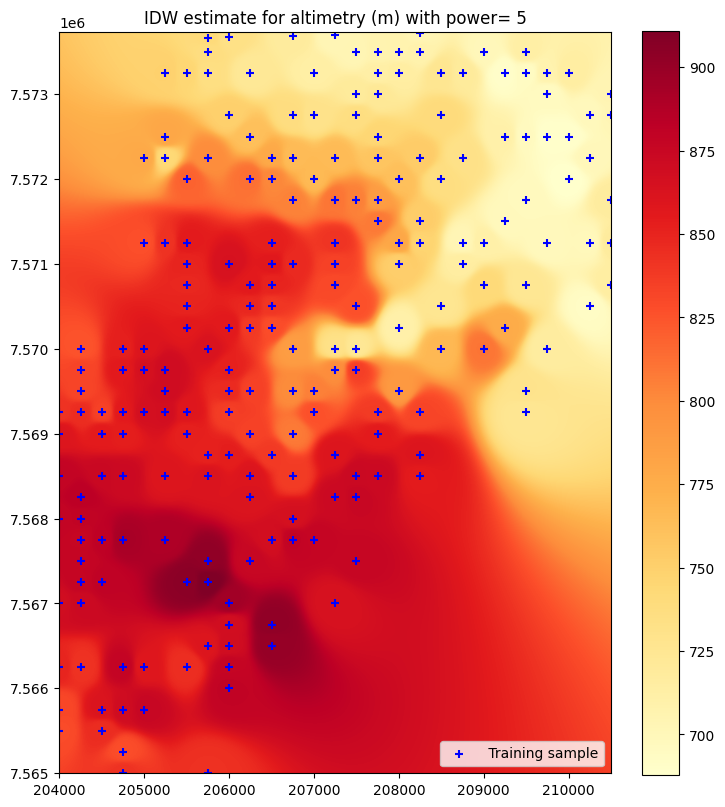

In [25]:
# Create a new figure and axis for the plot with a specific size
fig, ax = plt.subplots(figsize=(8, 10))

# Display the interpolated data as an image on the axis
# Note: By default, imshow assumes that the pixel coordinate origin (0,0) starts at the top left corner.
# However, our interpolated result idw_z2 has the pixel coordinate origin (0,0) starting at the lower left corner.
# That's why we need to specify origin='lower' to correctly display the image.
cax = ax.imshow(idw_z5, extent=(xmin, xmax, ymin, ymax), origin='lower', cmap='YlOrRd')

# Add the training samples as blue plus markers on the plot
train.plot(color='blue', ax=ax, marker='+', label=" Training sample")

# Add a colorbar to the plot with a specified size (fraction of the plot height)
cbar = plt.colorbar(cax, fraction=0.06)

# Add a legend to the plot to indicate the training sample
ax.legend()

# Set the title for the plot
plt.title('IDW estimate for altimetry (m) with power= 5')

# Display the final plot
plt.show()

In [26]:
#Kriging using pykrige
#Kriging is a group of geostatistical methods used to predict values at unobserved locations based on the values of observed points and their spatial relationships.
#The Python package pykrige supports 2D and 3D ordinary and universal kriging. 
!pip install pykrige

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 24.0 -> 25.2
[notice] To update, run: pip install --upgrade pip


Plotting Enabled

Adjusting data for anisotropy...
Initializing variogram model...
Coordinates type: 'euclidean' 

Using 'exponential' Variogram Model
Partial Sill: 10366.882583162227
Full Sill: 10366.882583162353
Range: 9888.373434121762
Nugget: 1.263193453113176e-10 



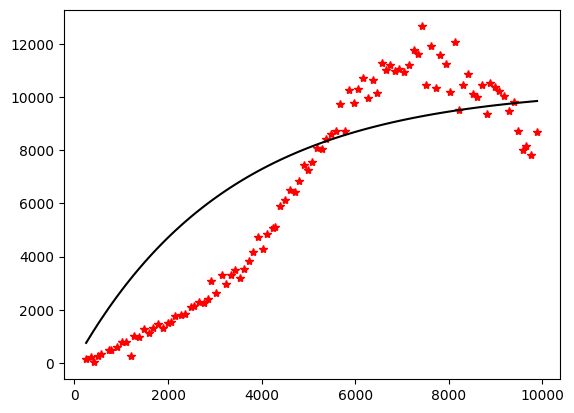

Calculating statistics on variogram model fit...
Q1 = 0.05924860920292201
Q2 = 0.1976978191548399
cR = 280.9317450490593 



In [27]:
# Import the necessary modules from the pykrige package
import pykrige.kriging_tools as kt
from pykrige.ok import OrdinaryKriging

# Create an instance of OrdinaryKriging for interpolation
krig_interp_exp = OrdinaryKriging(
    # Provide observed (x, y, z) data for interpolation
    x, y, z,
    # Set the variogram model to 'exponential' for a first test
    variogram_model='exponential',
    # Enable verbose mode for additional output
    verbose=True,
    # Enable plotting of variogram
    enable_plotting=True,
    # returns the statistics for the model 
    # Note that ideally Q1 is close to zero, Q2 is close to 1, and cR is as small as possible.
    enable_statistics=True,
    # Specify the number of lags for variogram analysis. 
    # This is the number of discrete distances used for coamparing data. 
    # The lags can be thought of as bins which contain the comparisons between points at a specific distance.
    nlags=100)

Plotting Enabled

Adjusting data for anisotropy...
Initializing variogram model...
Coordinates type: 'euclidean' 

Using 'spherical' Variogram Model
Partial Sill: 10511.956191154717
Full Sill: 10511.956191155436
Range: 9888.373434044066
Nugget: 7.180265133674343e-10 



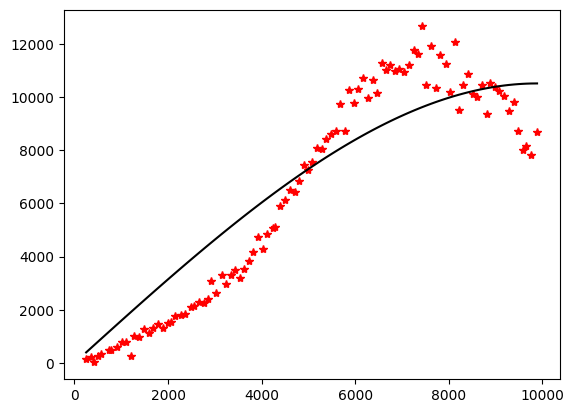

Calculating statistics on variogram model fit...
Q1 = 0.08201571542151888
Q2 = 0.36968420803932495
cR = 273.80339449268894 



In [28]:
#Spherical model
# Import the necessary modules from the pykrige package
import pykrige.kriging_tools as kt
from pykrige.ok import OrdinaryKriging

# Create an instance of OrdinaryKriging for interpolation
krig_interp_sph = OrdinaryKriging(
    # Provide observed (x, y, z) data for interpolation
    x, y, z,
    # Set the variogram model to 'spherical' for a first test
    variogram_model='spherical',
    # Enable verbose mode for additional output
    verbose=True,
    # Enable plotting of variogram
    enable_plotting=True,
    # returns the statistics for the model 
    # Note that ideally Q1 is close to zero, Q2 is close to 1, and cR is as small as possible.
    enable_statistics=True,
    # Specify the number of lags for variogram analysis. 
    # This is the number of discrete distances used for comparing data. 
    # The lags can be thought of as bins which contain the comparisons between points at a specific distance.
    nlags=100)

In [31]:
# Interpolating with kriging:
krig_z_sph, krig_sph_var = krig_interp_sph.execute("grid", gridx, gridy)

Executing Ordinary Kriging...



In [32]:
# Create a figure with two panels (subplots)
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 8))
# Plot data on the first panel
cax=axes[0].imshow(krig_z_sph, extent=(xmin, xmax, ymin, ymax), origin='lower', cmap='YlOrRd')
axes[0].set_title('Kriging Interpolation with spherical variogram')

# Add the training samples as blue plus markers on the plot
train.plot(color='blue', ax=axes[0], marker='+', label=" Training sample")

# Add a colorbar to the plot with a specified size (fraction of the plot height)
cbarx = plt.colorbar(cax, fraction=0.06)

# Add a legend to the plot to indicate the training sample
axes[0].legend()

# Plot data on the second panel
cay=axes[1].imshow(krig_sph_var, extent=(xmin, xmax, ymin, ymax), origin='lower', cmap="RdYlGn_r")
axes[1].set_title('Kriging variance')

# Add the training samples as blue plus markers on the plot
train.plot(color='blue', ax=axes[1], marker='+', label=" Training sample")

# Add a colorbar to the plot with a specified size (fraction of the plot height)
cbarx = plt.colorbar(cay, fraction=0.06)

# Add a legend to the plot to indicate the training sample
axes[1].legend()

# Adjust layout to prevent overlapping labels and titles
plt.tight_layout()

In [33]:
# Let’s get the error estimate for our our altimetry kriging:
# Getting the square root of the variance to calculate error
krig_sph_error= np.sqrt(krig_sph_var)

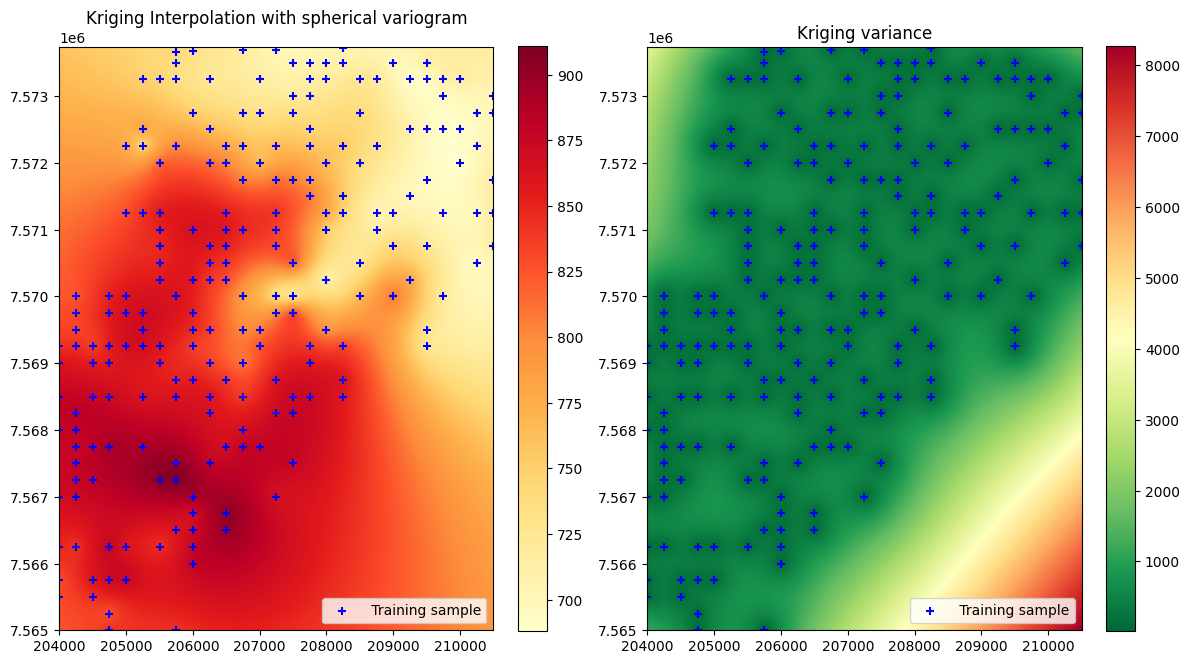

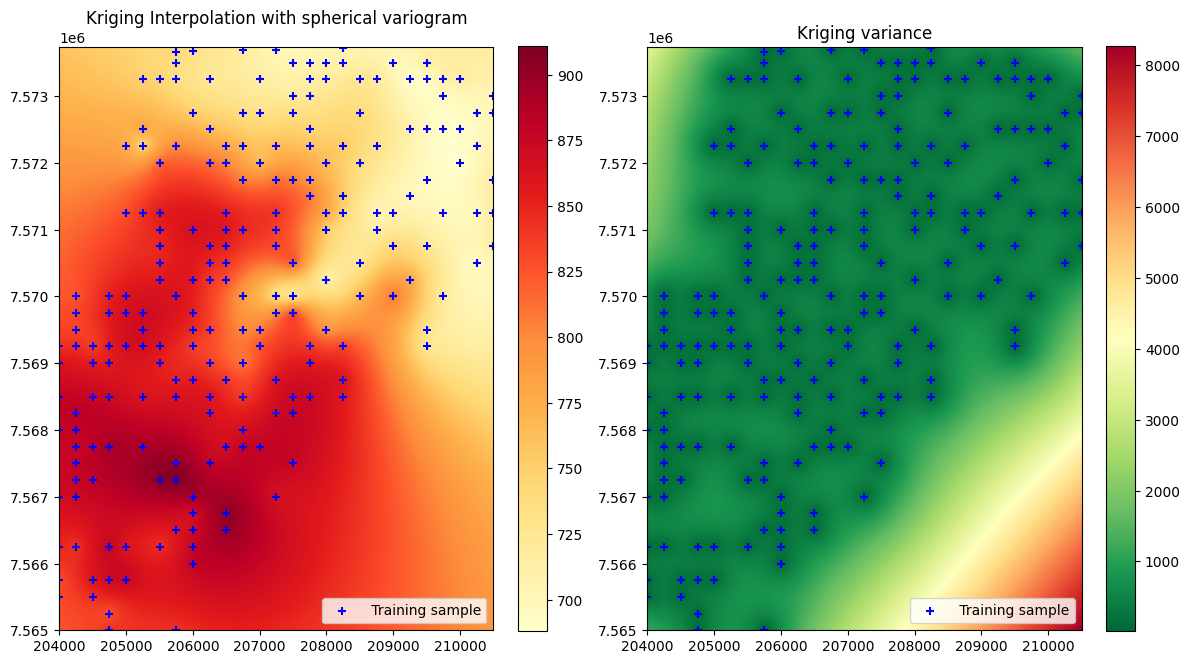

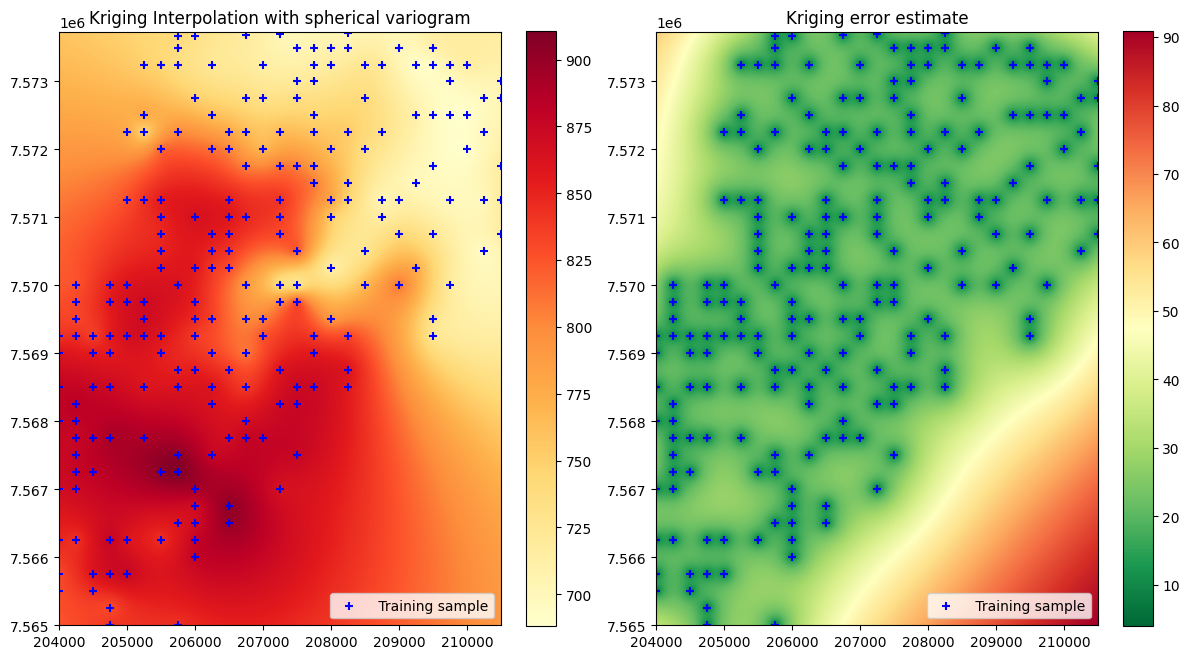

In [34]:
#let’s visualize the error map:
# Create a figure with two panels (subplots)
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 8))

# Plot data on the first panel
cax=axes[0].imshow(krig_z_sph, extent=(xmin, xmax, ymin, ymax), origin='lower', cmap='YlOrRd')
axes[0].set_title('Kriging Interpolation with spherical variogram')

# Add the training samples as blue plus markers on the plot
train.plot(color='blue', ax=axes[0], marker='+', label=" Training sample")

# Add a colorbar to the plot with a specified size (fraction of the plot height)
cbarx = plt.colorbar(cax, fraction=0.06,ax=axes[0])

# Add a legend to the plot to indicate the training sample
axes[0].legend()

# Plot data on the second panel
cay=axes[1].imshow(krig_sph_error, extent=(xmin, xmax, ymin, ymax), origin='lower', cmap="RdYlGn_r")
axes[1].set_title('Kriging error estimate')

# Add the training samples as blue plus markers on the plot
train.plot(color='blue', ax=axes[1], marker='+', label=" Training sample")

# Add a colorbar to the plot with a specified size (fraction of the plot height)
cbarx = plt.colorbar(cay, fraction=0.06,ax=axes[1])

# Add a legend to the plot to indicate the training sample
axes[1].legend()

# Adjust layout to prevent overlapping labels and titles
plt.tight_layout()
plt.show()

In [35]:
# Getting the square root of the variance to calculaet error
krig_sph_error= np.sqrt(krig_sph_var)

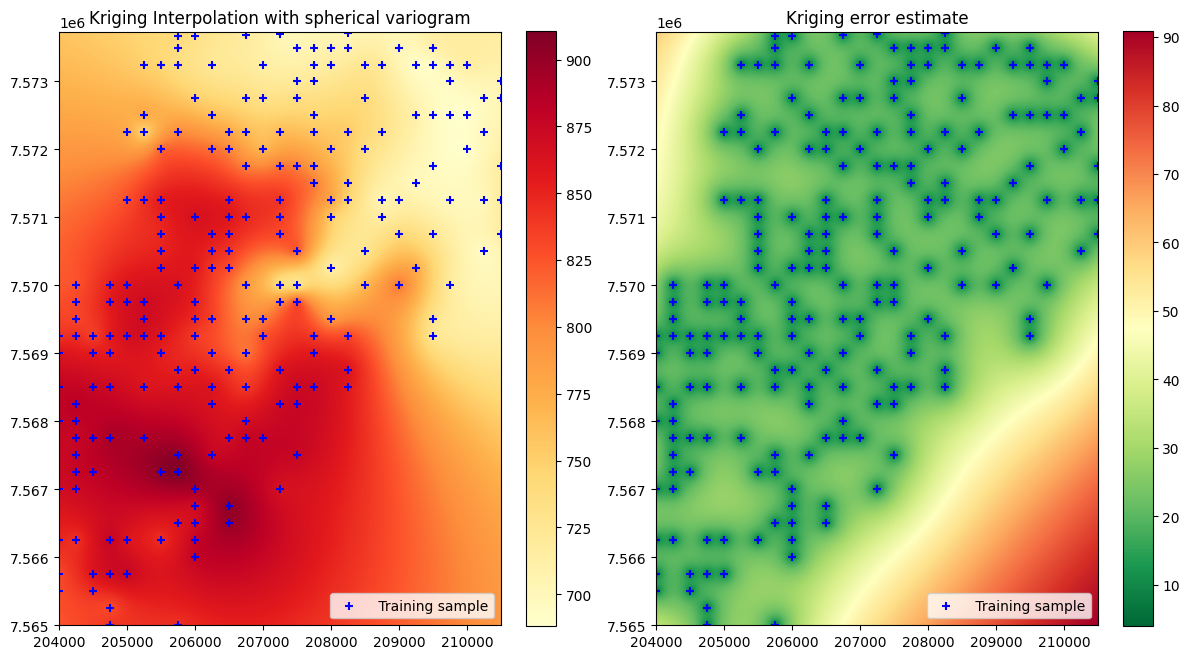

In [36]:
#let’s visualize the error map:
# Create a figure with two panels (subplots)
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 8))

# Plot data on the first panel
cax=axes[0].imshow(krig_z_sph, extent=(xmin, xmax, ymin, ymax), origin='lower', cmap='YlOrRd')
axes[0].set_title('Kriging Interpolation with spherical variogram')

# Add the training samples as blue plus markers on the plot
train.plot(color='blue', ax=axes[0], marker='+', label=" Training sample")

# Add a colorbar to the plot with a specified size (fraction of the plot height)
cbarx = plt.colorbar(cax, fraction=0.06,ax=axes[0])

# Add a legend to the plot to indicate the training sample
axes[0].legend()

# Plot data on the second panel
cay=axes[1].imshow(krig_sph_error, extent=(xmin, xmax, ymin, ymax), origin='lower', cmap="RdYlGn_r")
axes[1].set_title('Kriging error estimate')

# Add the training samples as blue plus markers on the plot
train.plot(color='blue', ax=axes[1], marker='+', label=" Training sample")

# Add a colorbar to the plot with a specified size (fraction of the plot height)
cbarx = plt.colorbar(cay, fraction=0.06,ax=axes[1])

# Add a legend to the plot to indicate the training sample
axes[1].legend()

# Adjust layout to prevent overlapping labels and titles
plt.tight_layout()
plt.show()

In [37]:
## Evaluating the performance of different interpolation models
#We can extract values from a raster image represented by a numpy.ndarray using point locations by following these steps:
#1. Convert the point locations in the geodataframe to the same coordinate system as the raster image, if necessary.
#2. Convert the location of the test points from coordinates to col,row locations using the `affine` library.
#3. Extract the values from the raster image at the pixel coordinates of the points using numpy indexing.
!pip install affine -q


[notice] A new release of pip is available: 24.0 -> 25.2
[notice] To update, run: pip install --upgrade pip


In [38]:
# Import the Affine class from the affine module
from affine import Affine

# Create an Affine object with specified coefficients that maps from pixels to coordinates
aff = Affine(10.0, 0.0, xmin-5, 0.0, -10.0, ymin-5)

# Compute the inverse affine that will map from coordinates to pixel
inv_aff= ~aff

In [39]:
#Use the inverse affine inv_aff to extract the col,row equivalent coordinates for each test point:
# Transform geometry coordinates to column and row indices by applying (*) the inverse of the affine transformation
test['col'], test['row'] = inv_aff * (test.geometry.x, test.geometry.y)

# Inspect the results
test

,FID,Avg_z,geometry,col,row
9,10,703.0,POINT Z (208500 7573720 703),450.5,-872.5
164,165,840.0,POINT Z (206250 7571750 840),225.5,-675.5
139,140,805.0,POINT Z (208250 7569500 805),425.5,-450.5
46,47,719.0,POINT Z (206750 7573000 719),275.5,-800.5
94,95,742.0,POINT Z (208500 7572250 742),450.5,-725.5
...,...,...,...,...,...
324,325,882.0,POINT Z (207000 7567250 882),300.5,-225.5
258,259,863.0,POINT Z (206000 7568500 863),200.5,-350.5
167,168,840.0,POINT Z (207250 7569250 840),325.5,-425.5
157,158,817.0,POINT Z (207750 7569500 817),375.5,-450.5


In [40]:
def fp_arr_updn(arr):
    """
    Flip an array vertically (upside down).

    Parameters:
        arr (numpy.ndarray): Input array to be flipped.

    Returns:
        numpy.ndarray: Vertically flipped array.
    """

    # Get the total number of rows in the input array
    n_rows = arr.shape[0]
    
    # Create an index array with reversed row indices
    idx_reversed = np.arange(n_rows)[::-1]
    
    # Index the array using the reversed index values
    indexed_arr = arr[idx_reversed, :]
    
    return indexed_arr

In [41]:
# Add Nearest Neighbor (NN) estimate to the test dataset
test['NN_estimate'] = fp_arr_updn(nnb_z)[test.row.astype(int), test.col.astype(int)]

# Add Inverse Distance Weighting (IDW) estimate to the test dataset
test['IDW_estimate'] = fp_arr_updn(idw_z2)[test.row.astype(int), test.col.astype(int)]

# Add Spherical Kriging estimate to the test dataset
test['kriging_estimate'] = fp_arr_updn(krig_z_sph)[test.row.astype(int), test.col.astype(int)]

# Inspect the results
test

,FID,Avg_z,geometry,col,row,NN_estimate,IDW_estimate,kriging_estimate
9,10,703.0,POINT Z (208500 7573720 703),450.5,-872.5,703.0,722.518254,705.730110
164,165,840.0,POINT Z (206250 7571750 840),225.5,-675.5,812.0,803.655119,829.816741
139,140,805.0,POINT Z (208250 7569500 805),425.5,-450.5,832.0,806.852450,800.389984
46,47,719.0,POINT Z (206750 7573000 719),275.5,-800.5,737.0,748.721906,725.635298
94,95,742.0,POINT Z (208500 7572250 742),450.5,-725.5,736.0,746.295057,741.465866
...,...,...,...,...,...,...,...,...
324,325,882.0,POINT Z (207000 7567250 882),300.5,-225.5,864.0,859.190385,877.504959
258,259,863.0,POINT Z (206000 7568500 863),200.5,-350.5,861.0,851.416164,860.975958
167,168,840.0,POINT Z (207250 7569250 840),325.5,-425.5,826.0,822.531589,836.513181
157,158,817.0,POINT Z (207750 7569500 817),375.5,-450.5,837.0,813.019795,818.004599


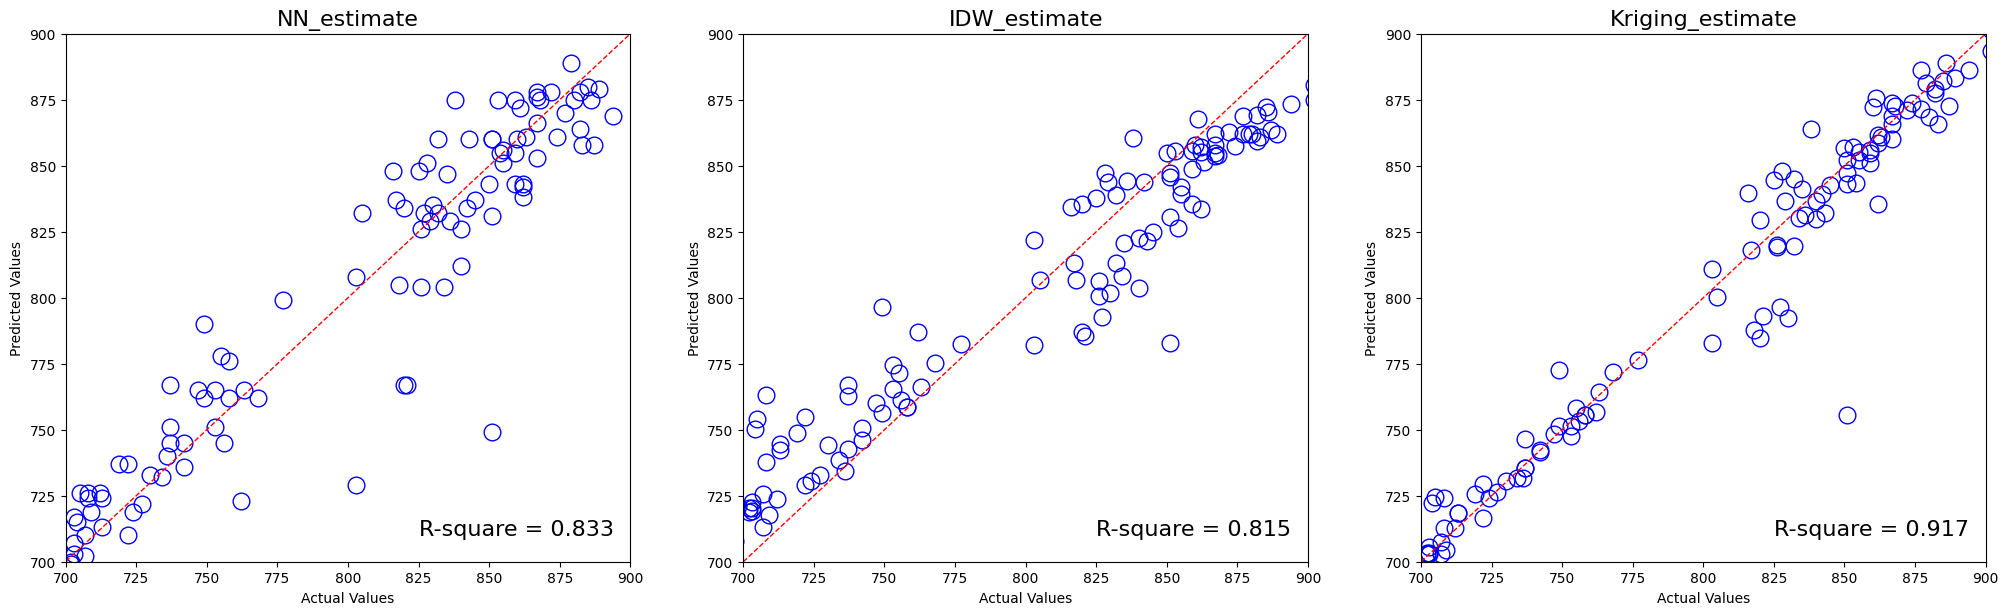

In [42]:
#Comparing actual values and predicted values
# Import  the necessary function to calculate the R-squared metric
from sklearn.metrics import r2_score 

## Define the first subplot - NN 
# Create a subplot with 1 row, 3 columns, and index 1 (first subplot)
plt.subplot(131)  # plt.subplot(nrows, ncols, index)

# Extract the actual values from the 'Avg_z' column of the 'test' dataframe
actual_values = test['Avg_z']

# Plot actual vs. estimated values as blue circles with no fill
plt.plot(actual_values, test['NN_estimate'], 
         "o", color='b', markersize=12, fillstyle='none')

# Plot a dashed red line representing y=x (perfect prediction)
plt.plot([700, 900], [700, 900], color='r', linewidth=1, linestyle="--") 

# Calculate R-square and display it as text on the plot
r2 = r2_score(actual_values, test.NN_estimate) ** 2
plt.text(825, 710, f'R-square = {r2:.3f}', fontsize=16)

# Set the title for the subplot
plt.title('NN_estimate', fontsize=16)

# Set labels for the x and y axes
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')

# Set limits for the x and y axes
plt.xlim([700, 900])
plt.ylim([700, 900])

## Define the second subplot - IDW
plt.subplot(132)  # Create a subplot with 1 row, 3 columns, and index 2 (second subplot)

# Plot actual vs. estimated values as blue circles with no fill
plt.plot(actual_values, test.IDW_estimate, 
         "o", color='b', markersize=12, fillstyle='none')

# Plot a dashed red line representing y=x (perfect prediction)
plt.plot([700, 900], [700, 900], color='r', linewidth=1, linestyle="--") 

# Calculate R-square and display it as text on the plot
r2_idw = r2_score(actual_values, test.IDW_estimate) ** 2
plt.text(825, 710, f'R-square = {r2_idw:.3f}', fontsize=16)

# Set the title for the subplot
plt.title('IDW_estimate', fontsize=16)

# Set labels for the x and y axes
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')

# Set limits for the x and y axes
plt.xlim([700, 900])
plt.ylim([700, 900])

## Define the third subplot - Kriging
plt.subplot(133)  # Create a subplot with 1 row, 3 columns, and index 3 (third subplot)

# Plot actual vs. estimated values as blue circles with no fill
plt.plot(actual_values, test.kriging_estimate, 
         "o", color='b', markersize=12, fillstyle='none')

# Plot a dashed red line representing y=x (perfect prediction)
plt.plot([700, 900], [700, 900], color='r', linewidth=1, linestyle="--") 

# Calculate R-square and display it as text on the plot
r2_kriging = r2_score(actual_values, test.kriging_estimate) ** 2
plt.text(825, 710, f'R-square = {r2_kriging:.3f}', fontsize=16)

# Set the title for the subplot
plt.title('Kriging_estimate', fontsize=16)

# Set labels for the x and y axes
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')

# Set limits for the x and y axes
plt.xlim([700, 900])
plt.ylim([700, 900])

# Adjust the layout of the subplots with specific spacing
plt.subplots_adjust(left=0.0, bottom=0.0, right=3.0, top=1.1, wspace=0.2, hspace=0.2)

# Display the plot
plt.show()

In [43]:
#The kriging interpolation generated the best result.
#we will export that surface as a raster for future use outside python:
!pip install rasterio -q


[notice] A new release of pip is available: 24.0 -> 25.2
[notice] To update, run: pip install --upgrade pip


In [45]:
import rasterio as rio

# Define the raster data and properties
raster_data = np.stack([fp_arr_updn(krig_z_sph.data)]) 

# Define metadata dictionary
metadata = {
    'driver': 'GTiff',                  # Format driver
    'dtype': 'float64',                 # Data type
    'nodata': None,                     # NoData value (replace with your value if applicable)
    'width': raster_data.shape[2],               # Width of the raster in pixels
    'height': raster_data.shape[1],              # Height of the raster in pixels
    'count': 1,                                  # Number of bands
    'crs': points.crs,                           # Coordinate Reference System (CRS)
    'transform':aff                              # Affine transformation
}

# Define the output raster file path
output_file = "Lab5_Data/kriged_output.tif"

# Write the raster data to the output file
with rio.open(output_file, 'w', **metadata) as dst:
    dst.write(raster_data) 

In [46]:
#Create an interactive map with samples and classified interpolated surface:
!pip install folium

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 24.0 -> 25.2
[notice] To update, run: pip install --upgrade pip


In [47]:
import numpy as np
from matplotlib.colors import ListedColormap
import folium
from folium.features import DivIcon

# set breaks and color map
brks = [700, 750, 800, 850, 900]
colors = ['#0000FF', '#00FF00', '#FFFF00', '#FF4500', '#FF0000']

# Classify the raster image using the defined thresholds
raster_class = np.digitize(fp_arr_updn(krig_z_sph), bins = brks, right=True)

# create a colormap for the classified image
cmap = ListedColormap(colors=colors)

# Convert the bounding box to the expected tuple format
gdf_wgs = points.to_crs(4326)
bounds = ((gdf_wgs.total_bounds[1], gdf_wgs.total_bounds[0]), (gdf_wgs.total_bounds[3], gdf_wgs.total_bounds[2]))

In [48]:
# Create folium map object
m=folium.Map(location=[-21.951886, -47.835438], tiles="cartodbpositron", zoom_start=12, control_scale=True)

# Add raster image layer
folium.raster_layers.ImageOverlay(
    image=raster_class,
    bounds=bounds,
    colormap=cmap,
    opacity=0.5,  # Set the opacity to 0.5
).add_to(m)

In [49]:
# Add an OpenStreetMap basemap to the map
folium.TileLayer('https://{s}.tile.openstreetmap.org/{z}/{x}/{y}.png',
                 attr='OpenStreetMap',
                 name='OpenStreetMap',
                 overlay=False).add_to(m)

# Add a Google Hybrid basemap to the map
folium.TileLayer('https://mt1.google.com/vt/lyrs=y&x={x}&y={y}&z={z}',
                 attr='Google Hybrid',
                 name='Google Hybrid',
                 overlay=False).add_to(m)

# Add a OpenTopoMap basemap to the map
folium.TileLayer('https://tile.opentopomap.org/{z}/{x}/{y}.png',
                 attr='OpenTopoMap',
                 name='OpenTopoMap',
                 overlay=False).add_to(m)

In [50]:
# Create Layer control panel
folium.map.LayerControl('bottomleft', collapsed= False).add_to(m)

In [51]:
# Add a Marker to the map at the specified location
# This marker uses a custom icon to display a floating text box
folium.Marker(
    location=[-21.951886, -47.9],  # Latitude and Longitude where the marker will be placed
    icon=DivIcon(
        icon_size=(210, 30),  # Size of the icon (width, height) in pixels
        icon_anchor=(0, 0),   # Point of the icon that will be placed at the marker's location
        html='''
            <div style="font-size: 15pt; background-color: #FFFFFF; padding: 5px; border-radius: 5px; border: 1px solid #000000; text-align: center;">
                <b>Elevation sampling locations</b>
            </div>
        '''
        # HTML content for the icon; uses inline CSS to style the text box
        # - `font-size: 15pt;` sets the font size
        # - `background-color: #FFFFFF;` sets the background color of the text box to white
        # - `padding: 5px;` adds space inside the text box around the text
        # - `border-radius: 5px;` rounds the corners of the text box
        # - `border: 1px solid #000000;` adds a black border around the text box
        # - `text-align: center;` centers the text inside the text box
    )
).add_to(m)  # Add the marker to the map object `m`

In [52]:
import pandas as pd
import branca
from branca.colormap import LinearColormap

# Convert a GeoDataFrame to a DataFrame by dropping the geometry column
# `gdf_wgs` is assumed to be a GeoDataFrame with a geometry column
data = pd.DataFrame(gdf_wgs.drop(columns='geometry'))

# Add latitude and longitude columns to the DataFrame
# Extract latitude and longitude from the geometry column of the GeoDataFrame
# `gdf_wgs.geometry.x` gives the longitude, and `gdf_wgs.geometry.y` gives the latitude
data["Latitude"] = gdf_wgs.geometry.y  # Latitude should be `gdf_wgs.geometry.y`
data["Longitude"] = gdf_wgs.geometry.x  # Longitude should be `gdf_wgs.geometry.x`

# Add the 'vars' column which represents some variable of interest (e.g., average elevation)
# `gdf_wgs.Avg_z` is assumed to be a column in the GeoDataFrame representing the variable
data["vars"] = gdf_wgs.Avg_z

# Add an 'id' column to the DataFrame
# `gdf_wgs.FID` is assumed to be a unique identifier for each feature
data["id"] = gdf_wgs.FID

# Define color mapping for visualization
# `colors` should be a list of color codes for the gradient
# `brks` should be a list of breakpoints or bins to categorize the variable values
colormap = LinearColormap(
    colors=colors,                # List of colors to use in the color gradient
    index=brks,                   # List of breakpoints for the color gradient
    vmin=min(data["vars"]),       # Minimum value for scaling the colormap
    vmax=max(data["vars"]),       # Maximum value for scaling the colormap
    caption='Variable Name'       # Label for the colormap legend
)


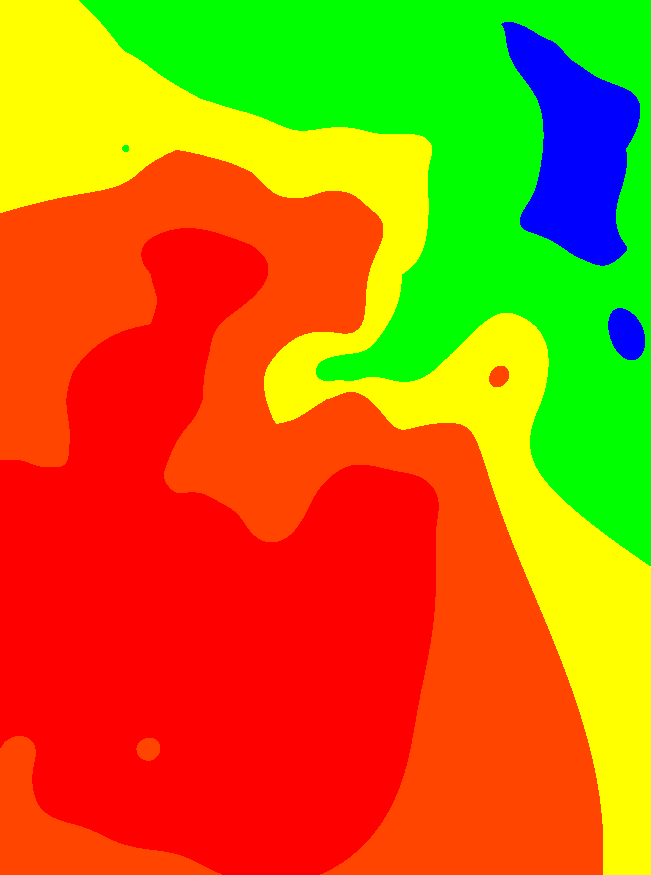

In [53]:
# Iterate over your data, creating a CircleMarker for each point
for lat, lng, vars, id in zip(data["Latitude"], data["Longitude"], data["vars"], data["id"]):
    # Create HTML content for the popup label
    popContent = '''
        <div style="font-family: Tahoma;">
            <b><font size="4">{}</font></b><br>
            <i><font color="green">elevation (m)</font></i><br>
            <i><font color="red">{}</font></i>
        </div>
    '''.format(id, vars)
    # Use HTML to configure the popup label using HTML formatting tags.
    # The <b> tag is used to make the text bold.
    # The <i> tag is used to make the text italic.
    # The <br> tag is used to insert a line break.

    # Create an IFrame for the popup content
    iframe = folium.IFrame(popContent)
    
    # Create a Popup with the IFrame and specify dimensions
    label = folium.Popup(iframe, parse_html=True, min_width=200, max_width=200)
    
    # Create a CircleMarker on the map at the specified latitude and longitude
    folium.CircleMarker(
        location=[lat, lng],      # Latitude and longitude for the CircleMarker
        popup=label,              # Popup label to display on click
        color=None,               # Border color of the CircleMarker (set to None for no border)
        fill=True,                # Fill the CircleMarker with color
        fill_color=colormap(vars), # Use the colormap to determine the fill color based on the variable value
        fill_opacity=0.7,         # Set the opacity of the fill color
        parse_html=False          # Set to False to prevent HTML parsing in the popup
    ).add_to(m)  # Add the CircleMarker to the map object `m`

# Create and add a color bar legend to the map
colorbar = branca.colormap.StepColormap(
    colors=colors,             # List of colors for the gradient
    index=brks,               # List of breakpoints or bins for the color gradient
    vmin=data['vars'].min(),  # Minimum value for scaling the colorbar
    vmax=data['vars'].max(),  # Maximum value for scaling the colorbar
    caption='Elevation (m)'   # Label for the colorbar legend
)

# Add the colorbar legend to the map
colorbar.add_to(m)

# Return or display the map
m

In [55]:
# # Save map as HTML file
m.save('classified_interpolation.html')